In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [7]:
car_data = pd.read_csv(r"C:\Users\mzalendo_ke\Downloads\car_data.csv")

In [11]:
car_data.head()

,Unnamed: 0,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,...,engine_type,num_of_cylinders,engine_size,fuel_system,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,dohc,four,130,mpfi,9.0,111,5000,21,27,13495
1,2,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,dohc,four,130,mpfi,9.0,111,5000,21,27,16500
2,3,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,...,ohcv,six,152,mpfi,9.0,154,5000,19,26,16500
3,4,audi,gas,std,four,sedan,fwd,front,99.8,176.6,...,ohc,four,109,mpfi,10.0,102,5500,24,30,13950
4,5,audi,gas,std,four,sedan,4wd,front,99.4,176.6,...,ohc,five,136,mpfi,8.0,115,5500,18,22,17450


In [15]:
# Check for missing or non-numeric values in key columns

missing_values = car_data.isnull().sum()

non_numeric_cols = car_data.select_dtypes(include=['object']).columns

In [17]:
car_data.isnull().sum()

Unnamed: 0           0
make                 0
fuel_type            0
aspiration           0
num_of_doors         0
body_style           0
drive_wheels         0
engine_location      0
wheel_base           0
length               0
width                0
height               0
curb_weight          0
engine_type          0
num_of_cylinders     0
engine_size          0
fuel_system          0
compression_ratio    0
horsepower           0
peak_rpm             0
city_mpg             0
highway_mpg          0
price                0
dtype: int64

In [19]:
# Convert relevant columns to numeric where possible

car_data['horsepower'] = pd.to_numeric(car_data['horsepower'], errors='coerce')

car_data['peak_rpm'] = pd.to_numeric(car_data['peak_rpm'], errors='coerce')

car_data['price'] = pd.to_numeric(car_data['price'], errors='coerce')

In [21]:
# Summary statistics for numerical columns

summary_stats = car_data.describe()

In [23]:
car_data.describe()

,Unnamed: 0,wheel_base,length,width,height,curb_weight,engine_size,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,103.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,59.322565,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,1.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,103.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,205.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [25]:
car_data["make"].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'mercedes-benz', 'mercury',
       'mitsubishi', 'nissan', 'peugot', 'plymouth', 'porsche', 'renault',
       'saab', 'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

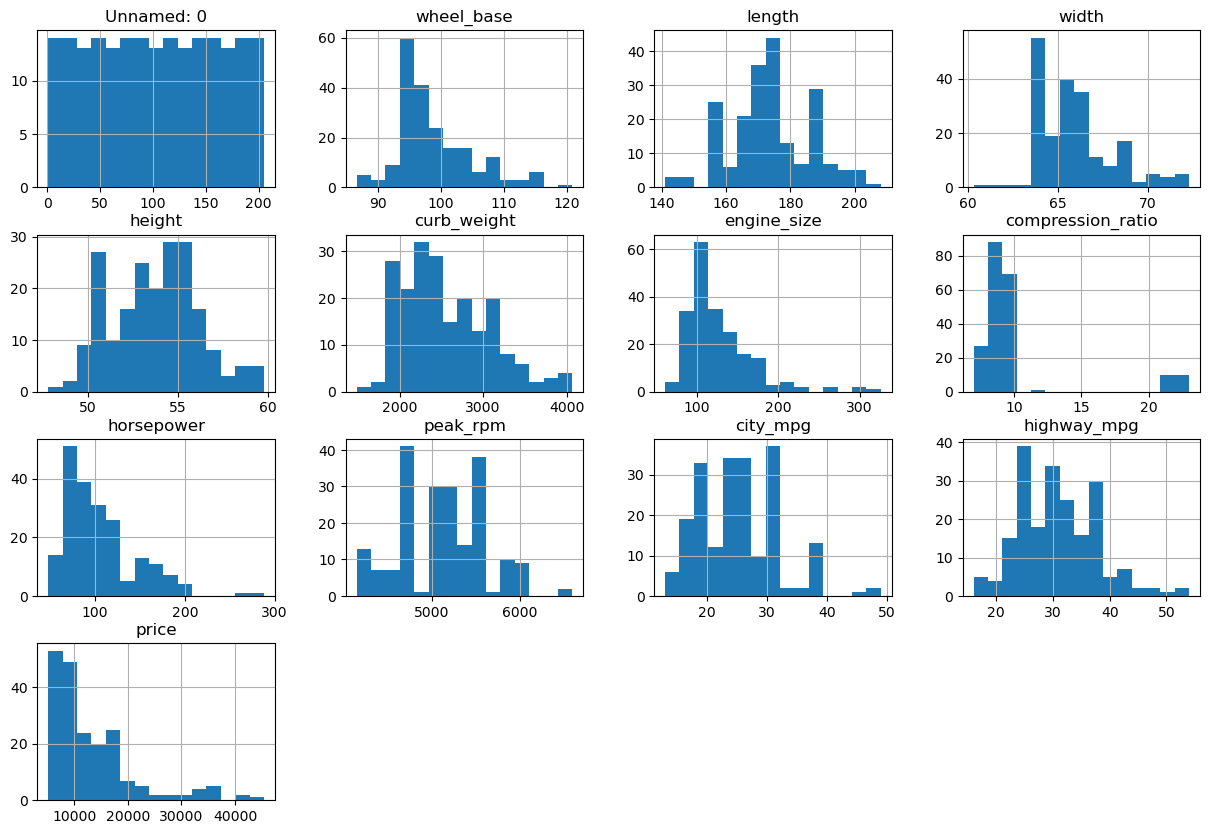

In [29]:
# Distribution of numerical features
car_data.hist(bins=15, figsize=(15, 10))
plt.show()

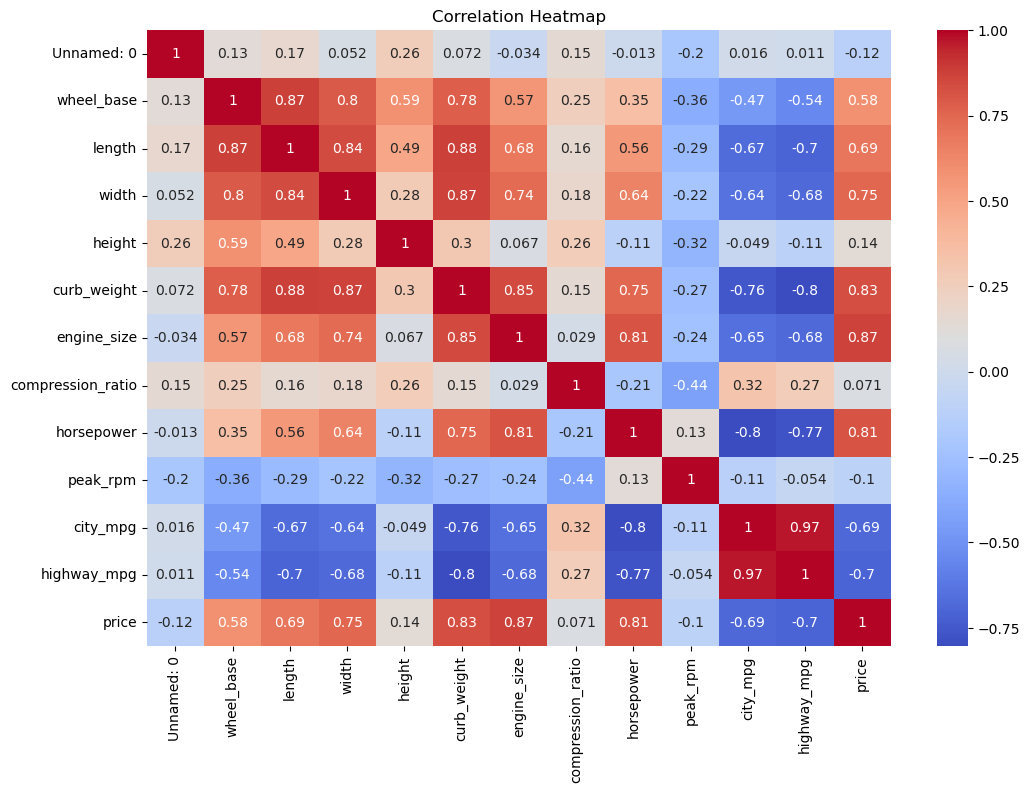

In [33]:
# Correlation heatmap for numerical features
numerical_features = car_data.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(12, 8))
sns.heatmap(numerical_features.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

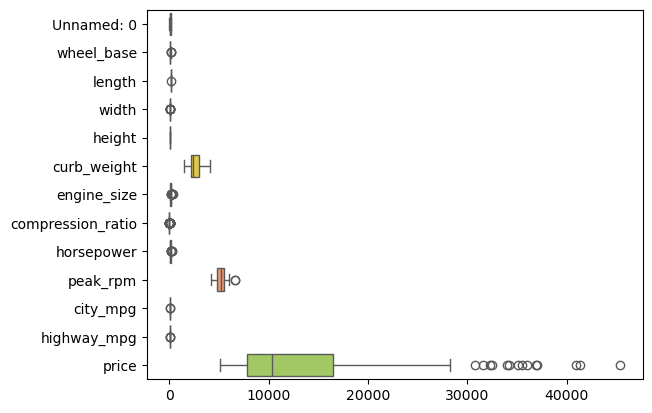

In [39]:
# Boxplot to check for outliers
sns.boxplot(data=car_data, orient="h", palette="Set2")
plt.show()

In [43]:
# Select features and target variable for regression
features = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'compression_ratio']
target = 'price'

In [45]:
# Prepare the dataset
X = car_data[features]
y = car_data[target]

In [47]:
# Handle missing values using mean imputation
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
y = y.fillna(y.mean())

In [49]:
# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [51]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
# Train a Random Forest Regressor
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [57]:
# Make predictions and evaluate the model
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae, mse, r2

(1542.51115831701, 5232218.8030829765, 0.9328962483395421)

In [61]:
# Feature Importance Analysis
feature_importances = model.feature_importances_
feature_names = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'compression_ratio']

C:\Users\mzalendo_ke\AppData\Local\Temp\ipykernel_16684\1831702077.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_names, palette="viridis")


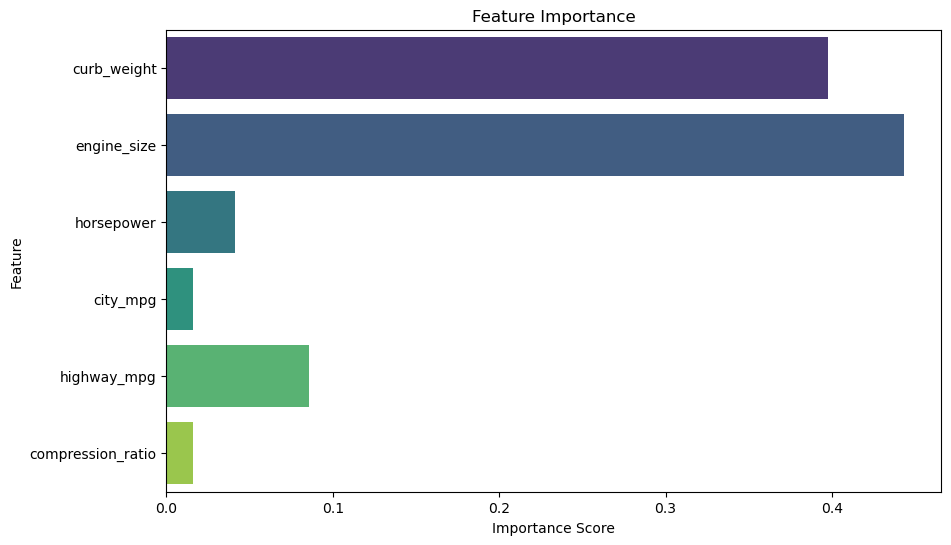

In [63]:
# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_names, palette="viridis")
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [67]:
# Hyperparameter Tuning using GridSearchCV
param_grid = {
'n_estimators': [50, 100, 200],
'max_depth': [None, 10, 20, 30],
'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
estimator=RandomForestRegressor(random_state=42),
param_grid=param_grid,
scoring='r2',
cv=5,
verbose=1,
n_jobs=-1
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='r2', verbose=1)

In [ ]:
# Evaluate the best model from GridSearch

best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)
grid_search.best_params_, mae_tuned, mse_tuned, r2_tuned